Train: (54000, 28, 28, 1) | Val: (6000, 28, 28, 1) | Test: (10000, 28, 28, 1)


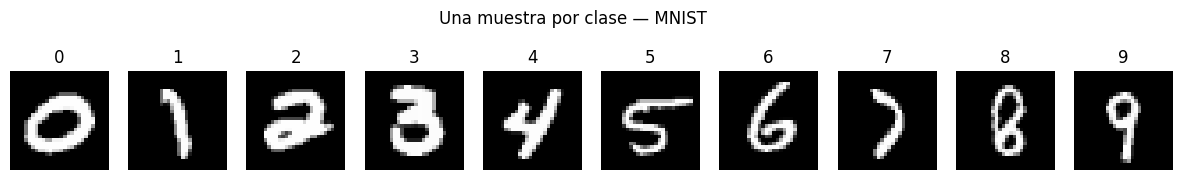

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

# Carga datos
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = x_train[..., np.newaxis]   # (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]    # (10000, 28, 28, 1)

x_val, x_train = x_train[:6000], x_train[6000:]
y_val, y_train = y_train[:6000], y_train[6000:]

print(f'Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}')

# Visualización rápida
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(x_train[idx, :, :, 0], cmap='gray')
    axes[i].set_title(str(i))
    axes[i].axis('off')
plt.suptitle('Una muestra por clase — MNIST', y=1.05)
plt.show()

In [30]:
# CNN base
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Base')

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
hist_cnn = cnn.fit(x_train, y_train,
                   batch_size=64, epochs=20,
                   validation_data=(x_val, y_val),
                   callbacks=[cb], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9334 - loss: 0.2145 - val_accuracy: 0.9812 - val_loss: 0.0609
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9787 - loss: 0.0713 - val_accuracy: 0.9850 - val_loss: 0.0464
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9842 - loss: 0.0520 - val_accuracy: 0.9895 - val_loss: 0.0409
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9865 - loss: 0.0434 - val_accuracy: 0.9893 - val_loss: 0.0417
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9895 - loss: 0.0350 - val_accuracy: 0.9902 - val_loss: 0.0358
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9909 - loss: 0.0287 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9914 - loss: 0.0266 - val_accuracy: 0.9883 - val_loss: 0.0458
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9929 - loss: 0.0224 - val_accuracy: 0.

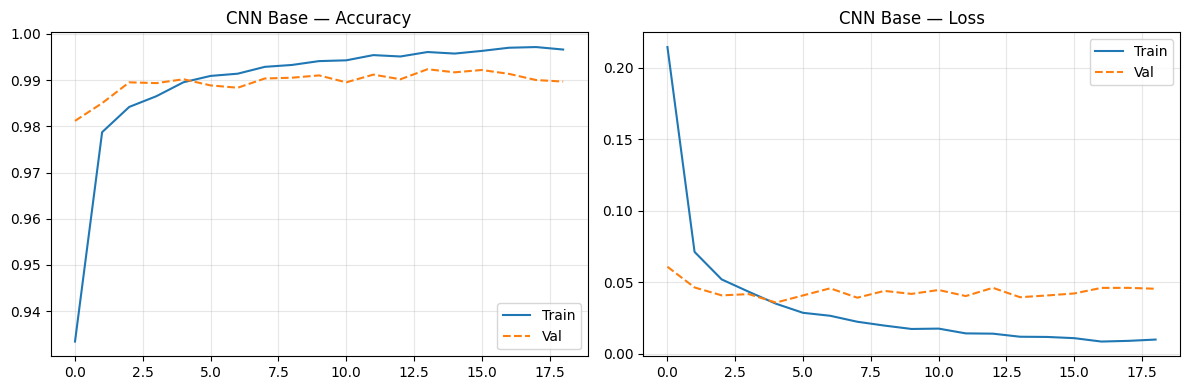

CNN Base → Test Accuracy: 0.9921 | Test Loss: 0.0298


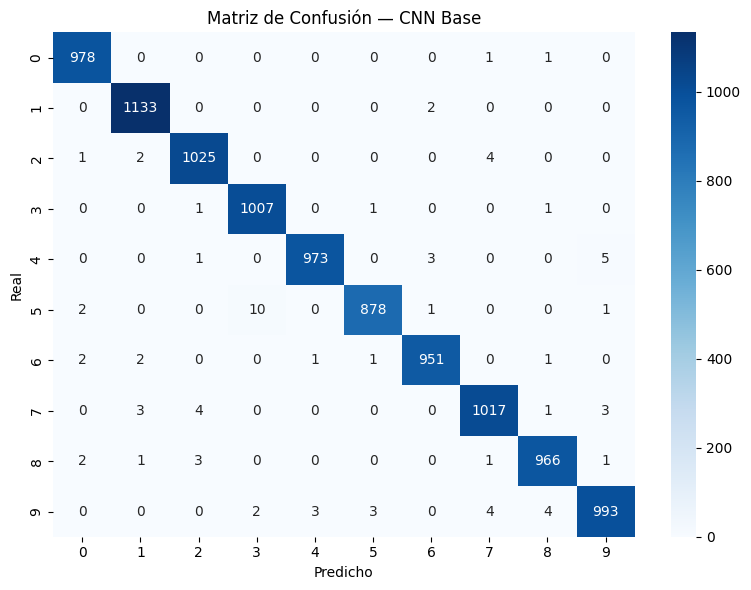

In [31]:
# Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_cnn.history['accuracy'],     label='Train')
ax1.plot(hist_cnn.history['val_accuracy'], label='Val', linestyle='--')
ax1.set_title('CNN Base — Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(hist_cnn.history['loss'],     label='Train')
ax2.plot(hist_cnn.history['val_loss'], label='Val', linestyle='--')
ax2.set_title('CNN Base — Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluación
loss_cnn, acc_cnn = cnn.evaluate(x_test, y_test, verbose=0)
print(f'CNN Base → Test Accuracy: {acc_cnn:.4f} | Test Loss: {loss_cnn:.4f}')

# Matriz de confusión
y_pred_cnn = np.argmax(cnn.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión — CNN Base')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

In [32]:
# Metodo transfer learning
inp = keras.Input(shape=(28, 28, 1))
x = layers.UpSampling2D(size=(4, 4))(inp)          # 28 → 112 px
x = layers.Conv2D(3, (1,1), activation='relu')(x)  # 1 canal → 3 canales

base = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')
base.trainable = False  # Feature extraction: base congelada

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(10, activation='softmax')(x)

tl = keras.Model(inp, out, name='TransferLearning_MobileNetV2')

tl.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
tl.summary()

cb_tl = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')
hist_tl = tl.fit(x_train, y_train,
                 batch_size=64, epochs=20,
                 validation_data=(x_val, y_val),
                 callbacks=[cb_tl], verbose=1)

/tmp/ipykernel_1559/1870338851.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=(112, 112, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 112, 112, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,248 (9.24 MB)

 Trainable params: 165,264 (645.56 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 71s 58ms/step - accuracy: 0.1104 - loss: 2.3027 - val_accuracy: 0.1118 - val_loss: 2.3009
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1118 - val_loss: 2.3008
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1118 - val_loss: 2.3008
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1118 - val_loss: 2.3008
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1118 - val_loss: 2.3008
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.1124 - loss: 2.3014 - val_accuracy: 0.1118 - val_loss: 2.3008


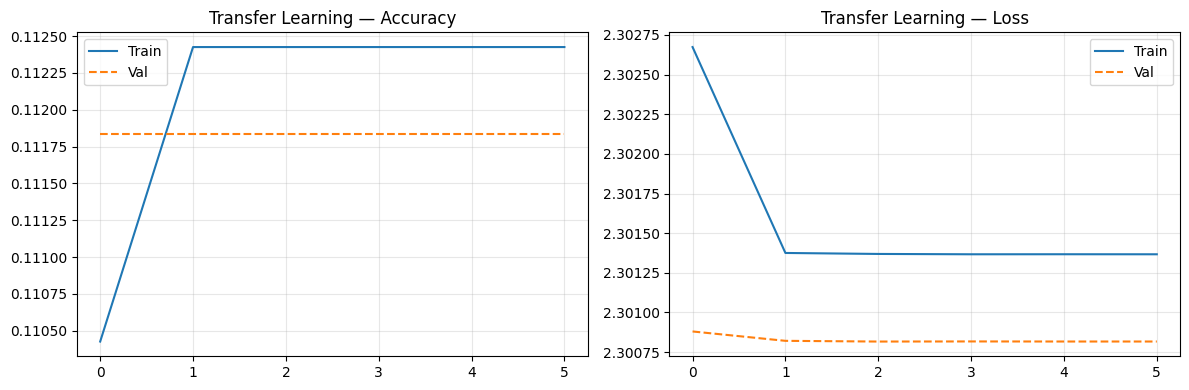

Transfer Learning → Test Accuracy: 0.1135 | Test Loss: 2.3011


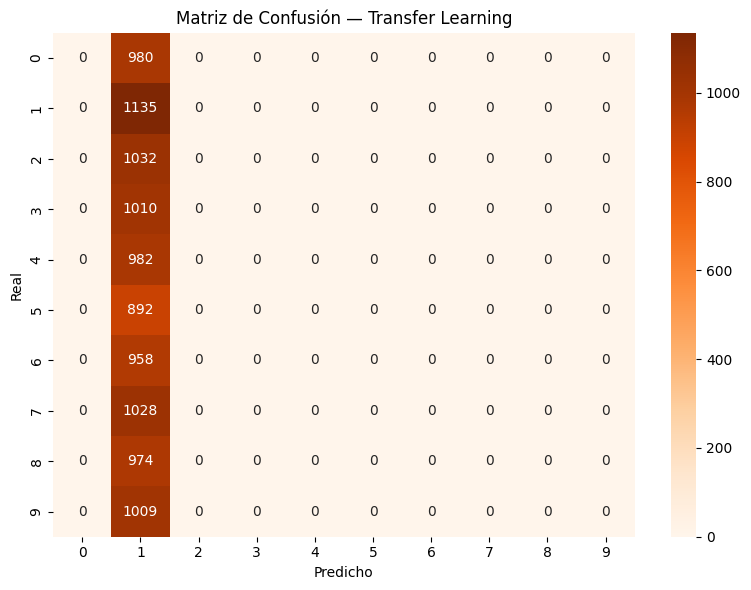

In [33]:
# Curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_tl.history['accuracy'],     label='Train')
ax1.plot(hist_tl.history['val_accuracy'], label='Val', linestyle='--')
ax1.set_title('Transfer Learning — Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(hist_tl.history['loss'],     label='Train')
ax2.plot(hist_tl.history['val_loss'], label='Val', linestyle='--')
ax2.set_title('Transfer Learning — Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluación
loss_tl, acc_tl = tl.evaluate(x_test, y_test, verbose=0)
print(f'Transfer Learning → Test Accuracy: {acc_tl:.4f} | Test Loss: {loss_tl:.4f}')

# Matriz de confusión
y_pred_tl = np.argmax(tl.predict(x_test, verbose=0), axis=1)
cm_tl = confusion_matrix(y_test, y_pred_tl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión — Transfer Learning')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout(); plt.show()

  Modelo                      Accuracy     Loss
  CNN Base                      0.9921   0.0298
  Transfer Learning             0.1135   2.3011
  Diferencia                  -87.86 pp


/tmp/ipykernel_1559/2238449758.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


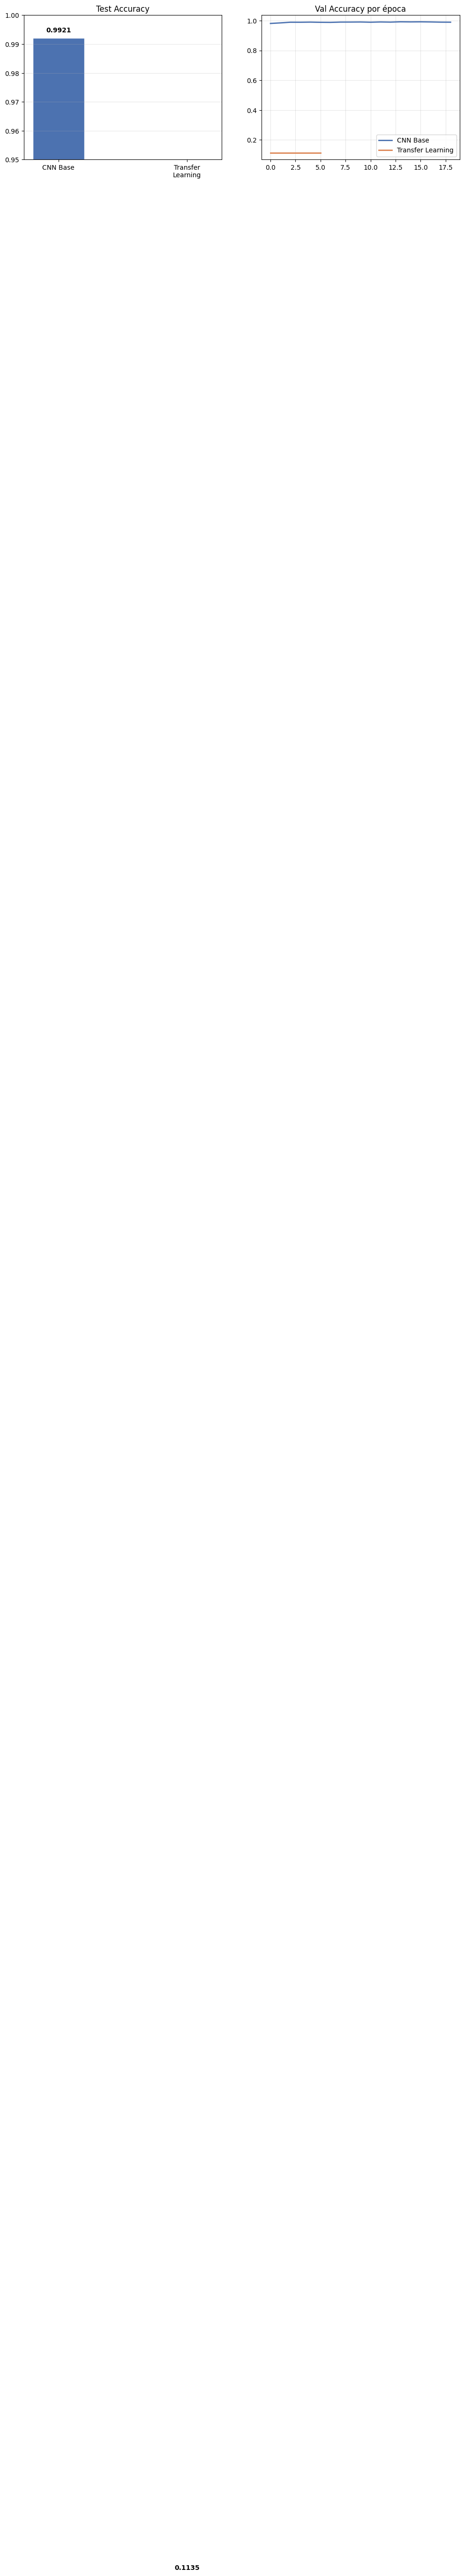

In [34]:
# Tabla resumen
print('='*50)
print(f'  {"Modelo":<25} {"Accuracy":>10} {"Loss":>8}')
print('='*50)
print(f'  {"CNN Base":<25} {acc_cnn:>10.4f} {loss_cnn:>8.4f}')
print(f'  {"Transfer Learning":<25} {acc_tl:>10.4f} {loss_tl:>8.4f}')
print('='*50)
print(f'  Diferencia               {(acc_tl - acc_cnn)*100:>+9.2f} pp')

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nombres = ['CNN Base', 'Transfer\nLearning']
colores = ['#4c72b0', '#dd8452']

bars = axes[0].bar(nombres, [acc_cnn, acc_tl], color=colores, width=0.4, edgecolor='white')
for bar, v in zip(bars, [acc_cnn, acc_tl]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('Test Accuracy'); axes[0].set_ylim(0.95, 1.0); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(hist_cnn.history['val_accuracy'], label='CNN Base',          color=colores[0], linewidth=2)
axes[1].plot(hist_tl.history['val_accuracy'],  label='Transfer Learning', color=colores[1], linewidth=2)
axes[1].set_title('Val Accuracy por época'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()